# Royal Speech Influence on Parliamentary Discourse

**Research question:** Do the monarch's public speeches cause a measurable shift in the vocabulary used in parliamentary debate in the quarters that follow?

**Approach:**
1. Load and preprocess both corpora separately — royal speeches and Hansard debates
2. Aggregate to quarter level
3. For each quarter containing royal speeches, extract the top 25 TF-IDF terms (V(s)) — words distinctive to that quarter's royal speeches vs all other royal speeches
4. Filter V(s) against the previous quarter's parliamentary vocabulary to remove already-ambient terms
5. Measure uptake of V(s) in parliamentary debates in the 2 quarters before and after each royal speech quarter
6. Run an event-study regression: `uptake ~ post + offset + quarter fixed effects`
7. Repeat with a placebo vocabulary (random parliamentary words not in V(s)) as a control

**Data required:**
- `csv_files/UK_monarch_speeches.csv` — royal speeches
- `csv_files/hansard.csv` — Hansard parliamentary debates

**Checkpoints:** preprocessed CSVs are saved to `SAVE_PATH` (set in Cell 2) to avoid rerunning spaCy lemmatisation

## 0. Imports and configuration

In [2]:
import re
import random
import nltk
import spacy
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

from pathlib import Path
from tqdm.auto import tqdm
from nltk.tokenize import word_tokenize
from nltk.stem import SnowballStemmer, WordNetLemmatizer, PorterStemmer
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

tqdm.pandas()

c:\Users\berti\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
ROYAL_DATA_PATH = Path('csv_files/UK_monarch_speeches.csv')
HANSARD_DATA_PATH = Path('csv_files/hansard.csv')

SAVE_PATH = Path('csv_files/')

YEAR_CUTOFF = 2002      # only use data from this year onwards
MIN_WORD_COUNT = 20     # drop parliamentary speeches shorter than this
N_TERMS = 100            # top TF-IDF terms to extract per royal speech quarter
BACKGROUND_TOP_K = 200  # number of ambient parliamentary terms to filter out
RANDOM_SEED = 123        # for reproducible placebo sampling

## 1. Load data

In [3]:
if not ROYAL_DATA_PATH.exists():
    raise FileNotFoundError(f"Could not find {ROYAL_DATA_PATH}. Run from the project root folder.")

royal_corpus_data = pd.read_csv(ROYAL_DATA_PATH, encoding='utf-8', encoding_errors='ignore', index_col=0)
royal_corpus_data = royal_corpus_data.rename(columns={'speech': 'text'})
royal_corpus_data = royal_corpus_data[royal_corpus_data['year'] >= YEAR_CUTOFF].copy()

print(f"Royal speeches loaded: {len(royal_corpus_data)} rows")
print(royal_corpus_data[['year', 'text']].head())

Royal speeches loaded: 374 rows
            year                                               text
date                                                               
2002-02-19  2002  Madam President, Madam Speaker:\n\nI thank you...
2002-02-25  2002  E te iwi, Ngai Tahu, tena koutou katoa (To the...
2002-02-25  2002  Tena koutou katoa.(Please accept my greetings....
2002-02-27  2002  Prime Minister, Premier, Mr. Crean, Mr. Rann, ...
2002-03-02  2002  Mr Prime Minister, Mr Secretary General, Presi...


In [4]:
if not HANSARD_DATA_PATH.exists():
    raise FileNotFoundError(f"Could not find {HANSARD_DATA_PATH}. Run from the project root folder.")

parliamentary_corpus_data = pd.read_csv(HANSARD_DATA_PATH, encoding='utf-8')
parliamentary_corpus_data = parliamentary_corpus_data.dropna(subset=['speaker'])
parliamentary_corpus_data.drop(
    columns=["file", "speech_id", "type", "speaker_id", "colnum", "time", "url"],
    inplace=True
)
parliamentary_corpus_data['date'] = pd.to_datetime(parliamentary_corpus_data['date'])
parliamentary_corpus_data = parliamentary_corpus_data[
    parliamentary_corpus_data['date'].dt.year >= YEAR_CUTOFF
].copy()

print(f"Parliamentary debates loaded: {len(parliamentary_corpus_data)} rows")
print(parliamentary_corpus_data.head())

C:\Users\berti\AppData\Local\Temp\ipykernel_13236\1327300850.py:4: DtypeWarning: Columns (0: type, 1: speaker_id, 2: colnum, 3: url) have mixed types. Specify dtype option on import or set low_memory=False.
  parliamentary_corpus_data = pd.read_csv(HANSARD_DATA_PATH, encoding='utf-8')


Parliamentary debates loaded: 1468265 rows
              date          speaker                    section  \
3151630 2002-01-08  James Clappison  Middle East Peace Process   
3151631 2002-01-08    Helen Jackson  Middle East Peace Process   
3151632 2002-01-08   Khalid Mahmood  Middle East Peace Process   
3151633 2002-01-08       Jack Straw  Middle East Peace Process   
3151634 2002-01-08  James Clappison  Middle East Peace Process   

                                                      text  word_count  
3151630  What recent representations he has received co...          12  
3151631  What recent discussions he has had with Palest...          17  
3151632  What diplomatic measures the UK Government are...          19  
3151633  Her Majesty's Government are fully engaged wit...         101  
3151634  What is the Foreign Secretary's response to th...         105  


## 2. Preprocessing

Both corpora are lemmatised identically using spaCy (`en_core_web_sm`). Preprocessing is applied once and checkpointed — reload from the checkpoint on subsequent runs to avoid reprocessing.

**This step is slow on the full Hansard corpus (~2.5M rows). Use `preprocess_lemma_batch` which processes in batches for speed.**

In [5]:
def download_nltk_resources():
    required = ['wordnet', 'stopwords', 'punkt', 'punkt_tab']
    for resource in required:
        try:
            nltk.data.find(f'tokenizers/{resource}' if 'punkt' in resource else f'corpora/{resource}')
        except LookupError:
            nltk.download(resource)

download_nltk_resources()

try:
    sp = spacy.load('en_core_web_sm')
except OSError:
    from spacy.cli import download as spacy_download
    print("Downloading spaCy model...")
    spacy_download('en_core_web_sm')
    sp = spacy.load('en_core_web_sm')

STOP_WORDS = set(stopwords.words('english'))

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\berti\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [6]:
def preprocess_lemma_batch(texts, batch_size=500):
    results = []
    for doc in tqdm(
        sp.pipe(texts, batch_size=batch_size, disable=["ner", "parser"]),
        total=len(texts),
        desc="Lemmatising"
    ):
        tokens = [
            token.lemma_.lower()
            for token in doc
            if not token.is_stop
            and not token.is_punct
            and token.lemma_.strip() != ''
            and len(token.lemma_) > 2
        ]
        results.append(' '.join(tokens))
    return results

In [36]:
parl_checkpoint = SAVE_PATH / 'parliamentary_preprocessed.csv'
royal_checkpoint =  SAVE_PATH / 'royal_preprocessed.csv'

if parl_checkpoint.exists() and royal_checkpoint.exists():
    print("Checkpoints found — loading preprocessed data...")
    parliamentary_corpus_data = pd.read_csv(parl_checkpoint)
    royal_corpus_data = pd.read_csv(royal_checkpoint)
    parliamentary_corpus_data['date'] = pd.to_datetime(parliamentary_corpus_data['date'])
    
    if 'date' in royal_corpus_data.columns:
        royal_corpus_data['date'] = pd.to_datetime(royal_corpus_data['date'])
    else:
        royal_corpus_data['date'] = pd.to_datetime(royal_corpus_data['year'].astype(str) + '-01-01')
    
    print("Loaded from checkpoints.")

else:
    print("No checkpoints found running preprocessing")

    parliamentary_corpus_data['text_clean'] = preprocess_lemma_batch(
        parliamentary_corpus_data['text'].astype(str).tolist()
    )
    royal_corpus_data['text_clean'] = preprocess_lemma_batch(
        royal_corpus_data['text'].astype(str).tolist()
    )

    parliamentary_corpus_data.to_csv(parl_checkpoint, index=False)
    royal_corpus_data.to_csv(royal_checkpoint, index=False)
    print(f"Checkpoints saved to {SAVE_PATH}")

Checkpoints found — loading preprocessed data...
Loaded from checkpoints.


In [37]:
parliamentary_corpus_data = parliamentary_corpus_data[
    parliamentary_corpus_data['word_count'] >= MIN_WORD_COUNT
].copy()

print(f"Parliamentary debates after word count filter: {len(parliamentary_corpus_data)}")
print(f"Royal speeches: {len(royal_corpus_data)}")

Parliamentary debates after word count filter: 3525914
Royal speeches: 374


## 3. Aggregate to quarter level

Royal speeches are aggregated by quarter so multiple speeches in the same quarter are treated as one unit. Parliamentary debates are similarly aggregated to produce one document per quarter for background filtering and uptake measurement.

In [38]:
# Assign quarter to both corpora
parliamentary_corpus_data['quarter'] = parliamentary_corpus_data['date'].dt.to_period('Q')
royal_corpus_data['date'] = pd.to_datetime(royal_corpus_data['date'])
royal_corpus_data['quarter'] = royal_corpus_data['date'].dt.to_period('Q')

# Aggregate parliamentary text by quarter
parl_quarterly = (
    parliamentary_corpus_data
    .groupby('quarter')['text_clean']
    .apply(lambda x: ' '.join(x.dropna()))
    .reset_index()
)

# Aggregate royal text by quarter
royal_quarterly = (
    royal_corpus_data
    .groupby('quarter')['text_clean']
    .apply(lambda x: ' '.join(x.dropna()))
    .reset_index()
)

print(f"Parliamentary quarters: {len(parl_quarterly)}")
print(f"Royal speech quarters:  {len(royal_quarterly)}")
print(f"Coverage: {royal_quarterly['quarter'].min()} to {royal_quarterly['quarter'].max()}")

Parliamentary quarters: 296
Royal speech quarters:  25
Coverage: 2002Q1 to 2026Q1


## 4. TF-IDF — extract distinctive royal speech vocabulary V(s)

TF-IDF is fitted on royal speech quarters only. A term scores highly if it is frequent in a given quarter's royal speeches but rare across other royal speech quarters. This isolates the distinctive agenda of each speech quarter.

In [39]:
# Fit TF-IDF on royal speeches
tfidf = TfidfVectorizer(
    ngram_range=(1, 1),
    min_df=0.01,     
    max_df=0.85,     
    max_features=10000
)
tfidf.fit(royal_quarterly['text_clean'])

royal_matrix = tfidf.transform(royal_quarterly['text_clean'])
feature_names = tfidf.get_feature_names_out()

print(f"Vocabulary size: {len(feature_names)}")

Vocabulary size: 9414


In [40]:
def get_top_terms(tfidf_row, feature_names, n=N_TERMS):
    scores = tfidf_row.toarray().flatten()
    top_indices = scores.argsort()[::-1][:n]
    return [(feature_names[i], scores[i]) for i in top_indices if scores[i] > 0]

royal_quarterly['top_terms'] = [
    get_top_terms(royal_matrix[i], feature_names)
    for i in range(royal_matrix.shape[0])
]

print("Example top terms for", royal_quarterly['quarter'].iloc[0])
print(royal_quarterly['top_terms'].iloc[0])

Example top terms for 2002Q1
[('jubilee', np.float64(0.3010797874454427)), ('golden', np.float64(0.20218000334141242)), ('canada', np.float64(0.16815509735383236)), ('australia', np.float64(0.154417478737345)), ('philip', np.float64(0.14195210403754707)), ('wales', np.float64(0.11431672511306343)), ('de', np.float64(0.10904824760363821)), ('et', np.float64(0.10752837947786736)), ('zealand', np.float64(0.10686750143703114)), ('region', np.float64(0.10385325875069594)), ('mayor', np.float64(0.0999401112335771)), ('canadian', np.float64(0.09826566828740137)), ('yorkshire', np.float64(0.09415973894085158)), ('midlands', np.float64(0.09415973894085158)), ('le', np.float64(0.09139912255618725)), ('newspaper', np.float64(0.08668787324352917)), ('mr', np.float64(0.08242380234438218)), ('des', np.float64(0.08188164475608074)), ('assembly', np.float64(0.08028794331878474)), ('la', np.float64(0.07526986563450715)), ('pride', np.float64(0.074860676135133)), ('regional', np.float64(0.07398519330256

## 5. Background filter — remove already-ambient parliamentary terms

For each royal speech quarter, the 200 most frequent terms in the previous quarter's parliamentary debates are identified. Any V(s) terms that appear in this background list are removed — they were already common in parliament before the speech and cannot be attributed to it.

In [41]:
def get_background_quarter(parl_df, current_quarter, top_k=BACKGROUND_TOP_K):
    prev_quarter = current_quarter - 1
    prev_text = parl_df[parl_df['quarter'] == prev_quarter]['text_clean']
    if len(prev_text) == 0:
        return set()
    cv = CountVectorizer(max_features=top_k)
    cv.fit(prev_text)
    return set(cv.get_feature_names_out())


def filter_vocab(top_terms, background_terms):
    return [(term, score) for term, score in top_terms if term not in background_terms]


royal_quarterly['vocab_filtered'] = royal_quarterly.apply(
    lambda row: filter_vocab(
        row['top_terms'],
        get_background_quarter(parl_quarterly, row['quarter'])
    ),
    axis=1
)

royal_quarterly['n_terms_after_filter'] = royal_quarterly['vocab_filtered'].apply(len)

print("Terms surviving background filter per quarter:")
print(royal_quarterly['n_terms_after_filter'].describe())
print()
print("If mean is very low (<5), reduce BACKGROUND_TOP_K.")
print("If mean is close to N_TERMS, increase BACKGROUND_TOP_K.")

Terms surviving background filter per quarter:
count     25.000000
mean      91.160000
std        4.651881
min       84.000000
25%       87.000000
50%       92.000000
75%       95.000000
max      100.000000
Name: n_terms_after_filter, dtype: float64

If mean is very low (<5), reduce BACKGROUND_TOP_K.
If mean is close to N_TERMS, increase BACKGROUND_TOP_K.


## 6. Uptake measurement

For each royal speech quarter, uptake is measured as the share of parliamentary words in each of the 2 preceding and 2 following quarters that belong to V(s). This produces a panel with one row per (royal quarter × offset).

The same measurement is repeated for a **placebo vocabulary** — 25 random parliamentary words not in V(s) — as a control.

In [42]:
def compute_uptake(debate_text, vocab_set):
    if not debate_text or len(debate_text) == 0:
        return None
    all_words = ' '.join(debate_text).split()
    if len(all_words) == 0:
        return None
    matches = sum(1 for w in all_words if w in vocab_set)
    return matches / len(all_words)


def get_placebo_vocab(parl_df, current_quarter, real_vocab_set, n=N_TERMS, seed=RANDOM_SEED):
    random.seed(seed)
    prev_quarter = current_quarter - 1
    prev_text = parl_df[parl_df['quarter'] == prev_quarter]['text_clean']
    if len(prev_text) == 0:
        return []
    all_words = set(' '.join(prev_text).split())
    available = list(all_words - real_vocab_set)
    if len(available) < n:
        return available
    return random.sample(available, n)

In [43]:
# Build placebo vocabulary for each royal quarter
royal_quarterly['placebo_vocab'] = royal_quarterly.apply(
    lambda row: get_placebo_vocab(
        parl_quarterly,
        row['quarter'],
        real_vocab_set=set(t for t, s in row['vocab_filtered'])
    ),
    axis=1
)

print("Placebo vocab size per quarter:")
print(royal_quarterly['placebo_vocab'].apply(len).describe())

Placebo vocab size per quarter:
count     25.0
mean     100.0
std        0.0
min      100.0
25%      100.0
50%      100.0
75%      100.0
max      100.0
Name: placebo_vocab, dtype: float64


In [44]:
# Compute uptake for both real and placebo vocabularies
records = []

for _, row in royal_quarterly.iterrows():
    real_set    = set(term for term, score in row['vocab_filtered'])
    placebo_set = set(row['placebo_vocab'])
    current_quarter = row['quarter']

    for offset in [-2, -1, 1, 2]:
        target_q = current_quarter + offset
        parl_row = parl_quarterly[parl_quarterly['quarter'] == target_q]
        if len(parl_row) == 0:
            continue
        debate_text = parl_row.iloc[0]['text_clean']

        real_uptake    = compute_uptake([debate_text], real_set)
        placebo_uptake = compute_uptake([debate_text], placebo_set)

        base = {
            'royal_quarter': str(current_quarter),
            'parl_quarter':  str(target_q),
            'offset': offset,
            'post': int(offset > 0)
        }

        if real_uptake is not None:
            records.append({**base, 'uptake': real_uptake, 'type': 'real'})
        if placebo_uptake is not None:
            records.append({**base, 'uptake': placebo_uptake, 'type': 'placebo'})

panel_df = pd.DataFrame(records)

panel_df.to_csv(SAVE_PATH / 'panel_df.csv', index=False)

print(f"Panel rows: {len(panel_df)}")
print(panel_df['type'].value_counts())
print(panel_df.head())

Panel rows: 196
type
real       98
placebo    98
Name: count, dtype: int64
  royal_quarter parl_quarter  offset  post    uptake     type
0        2002Q1       2001Q3      -2     0  0.012323     real
1        2002Q1       2001Q3      -2     0  0.009121  placebo
2        2002Q1       2001Q4      -1     0  0.011604     real
3        2002Q1       2001Q4      -1     0  0.009568  placebo
4        2002Q1       2002Q2       1     1  0.012307     real


## 7. Regression

Event-study OLS: `uptake ~ post + offset + C(royal_quarter)`

- `post` — the key coefficient: average jump in uptake after the royal speech quarter vs before
- `offset` — whether uptake fades or grows with distance from the speech quarter
- `C(royal_quarter)` — quarter fixed effects, absorbing all between-quarter variation

Run separately for real V(s) and placebo V(s). A positive significant `post` for real V(s) and a near-zero insignificant `post` for placebo is evidence the speech content is driving uptake.

In [45]:
real_df    = panel_df[panel_df['type'] == 'real'].copy()
placebo_df = panel_df[panel_df['type'] == 'placebo'].copy()

results_real = smf.ols(
    'uptake ~ post + offset + C(royal_quarter)',
    data=real_df
).fit(cov_type='HC1')

results_placebo = smf.ols(
    'uptake ~ post + offset + C(royal_quarter)',
    data=placebo_df
).fit(cov_type='HC1')

print("REAL V(s)")
print(f"  post coef:   {results_real.params['post']:+.6f}   p = {results_real.pvalues['post']:.4f}")
print(f"  offset coef: {results_real.params['offset']:+.6f}   p = {results_real.pvalues['offset']:.4f}")
print()
print("PLACEBO V(s)")
print(f"  post coef:   {results_placebo.params['post']:+.6f}   p = {results_placebo.pvalues['post']:.4f}")
print(f"  offset coef: {results_placebo.params['offset']:+.6f}   p = {results_placebo.pvalues['offset']:.4f}")

REAL V(s)
  post coef:   +0.000339   p = 0.5777
  offset coef: +0.000071   p = 0.7530

PLACEBO V(s)
  post coef:   -0.000515   p = 0.0281
  offset coef: +0.000174   p = 0.0185


## 8. Results plot

Coefficient plot showing real V(s) vs placebo side by side. If the speech is driving uptake, the real `post` coefficient should be larger and more significant than the placebo.

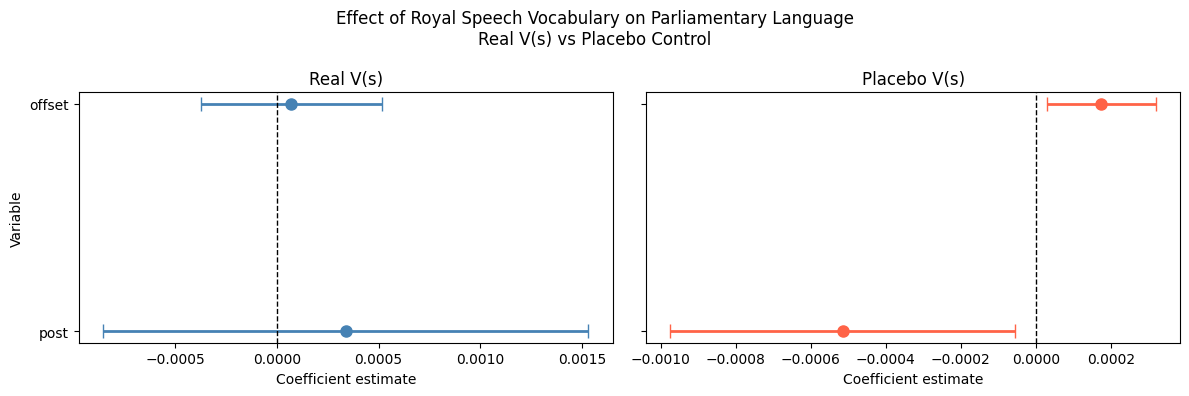

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, res, label, color in zip(
    axes,
    [results_real, results_placebo],
    ['Real V(s)', 'Placebo V(s)'],
    ['steelblue', 'tomato']
):
    params = res.params[['post', 'offset']]
    conf   = res.conf_int().loc[['post', 'offset']]

    ax.errorbar(
        x=params.values,
        y=params.index,
        xerr=[params.values - conf[0].values, conf[1].values - params.values],
        fmt='o', color=color, capsize=5, linewidth=2, markersize=8
    )
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.set_xlabel('Coefficient estimate')
    ax.set_title(label)

axes[0].set_ylabel('Variable')
plt.suptitle(
    'Effect of Royal Speech Vocabulary on Parliamentary Language\nReal V(s) vs Placebo Control',
    fontsize=12
)
plt.tight_layout()
plt.savefig(SAVE_PATH / 'results_plot.png', dpi=150, bbox_inches='tight')
plt.show()

We can see that the placebo made up of a random sample of vocabulary from parliamentary has similar post uptake confidence interval, reinforcing the conculusion that Royal vocabulary is not being adopted in parliamentary debate.

In [47]:
def fmt_coef(res, term):
    coef  = res.params[term]
    se    = res.bse[term]
    pval  = res.pvalues[term]
    stars = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.1 else ''
    return f"{coef:.6f}{stars}", f"({se:.6f})"

terms = ['post', 'offset']
table_data = []

for term in terms:
    coef_r, se_r = fmt_coef(results_real, term)
    coef_p, se_p = fmt_coef(results_placebo, term)
    table_data.append([term, coef_r, coef_p])
    table_data.append(['',   se_r,   se_p])

table_data.append(['', '─' * 14, '─' * 14])
table_data.append(['R²',       f"{results_real.rsquared:.4f}",     f"{results_placebo.rsquared:.4f}"])
table_data.append(['Adj. R²',  f"{results_real.rsquared_adj:.4f}", f"{results_placebo.rsquared_adj:.4f}"])
table_data.append(['N',        f"{int(results_real.nobs)}",        f"{int(results_placebo.nobs)}"])

table = pd.DataFrame(table_data, columns=['', 'Real V(s)', 'Placebo V(s)'])
print(table.to_string(index=False))

             Real V(s)   Placebo V(s)
   post       0.000339    -0.000515**
            (0.000608)     (0.000234)
 offset       0.000071     0.000174**
            (0.000226)     (0.000074)
        ────────────── ──────────────
     R²         0.9311         0.9855
Adj. R²         0.9059         0.9803
      N             98             98


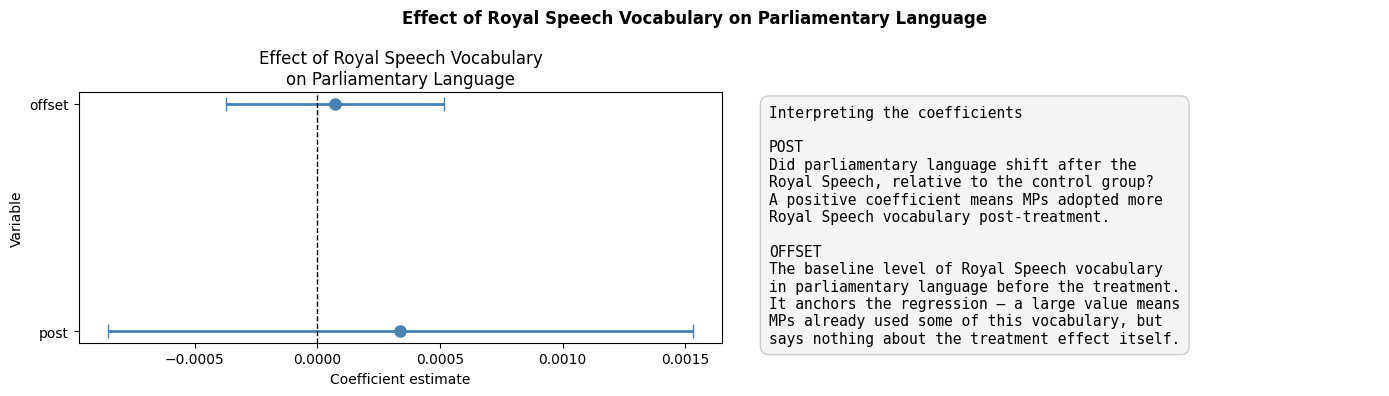

In [48]:
#Only plotting the real V(S): 

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
params = results_real.params[['post', 'offset']].values
conf   = results_real.conf_int().loc[['post', 'offset']].values

ax.errorbar(
    x=params,
    y=['post', 'offset'],
    xerr=[params - conf[:, 0], conf[:, 1] - params],
    fmt='o', color='steelblue', capsize=5, linewidth=2, markersize=8
)
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Coefficient estimate')
ax.set_ylabel('Variable')
ax.set_title('Effect of Royal Speech Vocabulary\non Parliamentary Language')

ax_text = axes[1]
ax_text.axis('off')

intuition = (
    "Interpreting the coefficients\n\n"
    "POST\n"
    "Did parliamentary language shift after the\n"
    "Royal Speech, relative to the control group?\n"
    "A positive coefficient means MPs adopted more\n"
    "Royal Speech vocabulary post-treatment.\n\n"
    "OFFSET\n"
    "The baseline level of Royal Speech vocabulary\n"
    "in parliamentary language before the treatment.\n"
    "It anchors the regression — a large value means\n"
    "MPs already used some of this vocabulary, but\n"
    "says nothing about the treatment effect itself."
)

ax_text.text(
    0.05, 0.95, intuition,
    transform=ax_text.transAxes,
    fontsize=10.5,
    verticalalignment='top',
    family='monospace',
    bbox=dict(boxstyle='round,pad=0.6', facecolor='#f5f5f5', edgecolor='#cccccc', linewidth=1)
)

plt.suptitle(
    'Effect of Royal Speech Vocabulary on Parliamentary Language',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig(SAVE_PATH / 'results_plot_real.png', dpi=150, bbox_inches='tight')
plt.show()